In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix)



In [2]:
# -----------------------------
# Load dataset
# -----------------------------
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




Logistic Regression Confusion Matrix:
[[ 62   1]
 [  2 106]]

KNN Confusion Matrix:
[[ 59   4]
 [  3 105]]

Random Forest Confusion Matrix:
[[ 59   4]
 [  1 107]]


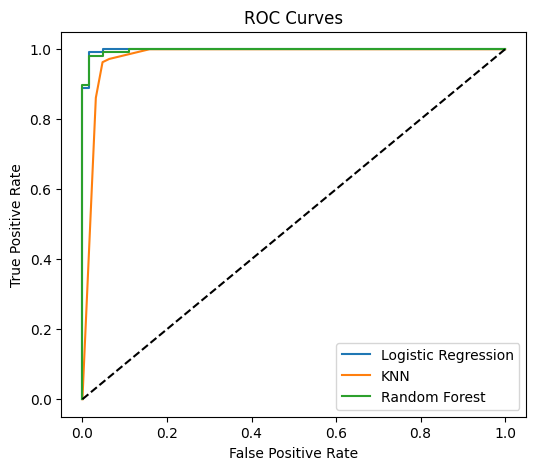

In [3]:
# -----------------------------
# Models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []

plt.figure(figsize=(6,5))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

    # Confusion matrix
    print(f"\n{name} Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()



In [4]:
# -----------------------------
# Results table
# -----------------------------
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
)

print("\nPerformance Comparison Table:")
print(results_df)



Performance Comparison Table:
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.982456   0.990654  0.981481  0.986047  0.997942
1                  KNN  0.959064   0.963303  0.972222  0.967742  0.978689
2        Random Forest  0.970760   0.963964  0.990741  0.977169  0.997208
